<a href="https://colab.research.google.com/github/Alaaeldinaly/lesson-5-assignment-titanic-eda/blob/main/titanic_eda_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1) Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_style("whitegrid")

2) Load the Titanic Dataset

In [6]:
df = pd.read_csv("Titanic-Dataset.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (891, 12)


3) Inspect the Data

In [7]:
print("First 5 rows:")
print(df.head())

print("\nLast 5 rows:")
print(df.tail())

print("\nData types:")
print(df.dtypes)

print("\nDescriptive statistics:")
print(df.describe(include="all"))

First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN

4) Basic Information About Missing Values

In [8]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


5) Create New Categorical Feature for Pclass

In [9]:
df["Pclass_Category"] = df["Pclass"].map({
    1: "First Class",
    2: "Second Class",
    3: "Third Class"
})

print(df[["Pclass", "Pclass_Category"]].head())

   Pclass Pclass_Category
0       3     Third Class
1       1     First Class
2       3     Third Class
3       1     First Class
4       3     Third Class


6) Create New Categorical Feature for Cabin

In [10]:
df["Cabin_Category"] = df["Cabin"].fillna("Unknown").astype(str).str[0]

print(df[["Cabin", "Cabin_Category"]].head(10))

  Cabin Cabin_Category
0   NaN              U
1   C85              C
2   NaN              U
3  C123              C
4   NaN              U
5   NaN              U
6   E46              E
7   NaN              U
8   NaN              U
9   NaN              U


7) Check Missing Values in Age

In [11]:
print("Missing values in Age before filling:")
print(df["Age"].isnull().sum())

Missing values in Age before filling:
177


8) Handle Missing Values in Age

In [12]:
# Fill missing age values with the median age
df["Age"] = df["Age"].fillna(df["Age"].median())

print("Missing values in Age after filling:")
print(df["Age"].isnull().sum())

Missing values in Age after filling:
0


**Insight:**  
I filled missing values in the `Age` column using the median because it is less affected by extreme values than the mean.

9) Create Family Feature

In [13]:
df["Family"] = df["SibSp"] + df["Parch"] + 1

print(df[["SibSp", "Parch", "Family"]].head())

   SibSp  Parch  Family
0      1      0       2
1      1      0       2
2      0      0       1
3      1      0       2
4      0      0       1


10) Passenger with Highest Fare

In [14]:
highest_fare_passenger = df.loc[df["Fare"].idxmax()]

print("Passenger with highest fare:")
print(highest_fare_passenger)

Passenger with highest fare:
PassengerId                     259
Survived                          1
Pclass                            1
Name               Ward, Miss. Anna
Sex                          female
Age                            35.0
SibSp                             0
Parch                             0
Ticket                     PC 17755
Fare                       512.3292
Cabin                           NaN
Embarked                          C
Pclass_Category         First Class
Cabin_Category                    U
Family                            1
Name: 258, dtype: object


11) Passenger with Largest Family Size

In [15]:
largest_family_passenger = df.loc[df["Family"].idxmax()]

print("Passenger with largest family size:")
print(largest_family_passenger)

Passenger with largest family size:
PassengerId                               160
Survived                                    0
Pclass                                      3
Name               Sage, Master. Thomas Henry
Sex                                      male
Age                                      28.0
SibSp                                       8
Parch                                       2
Ticket                               CA. 2343
Fare                                    69.55
Cabin                                     NaN
Embarked                                    S
Pclass_Category                   Third Class
Cabin_Category                              U
Family                                     11
Name: 159, dtype: object


12) Pandas Series Functionality

In [16]:
age_series = df["Age"]

print("Age Series:")
print(age_series.head())

print("\nSeries statistics:")
print(age_series.describe())

Age Series:
0    22.0
1    38.0
2    26.0
3    35.0
4    35.0
Name: Age, dtype: float64

Series statistics:
count    891.000000
mean      29.361582
std       13.019697
min        0.420000
25%       22.000000
50%       28.000000
75%       35.000000
max       80.000000
Name: Age, dtype: float64


13) Create and Manipulate a Small DataFrame

In [17]:
sample_df = pd.DataFrame({
    "Name": ["Ali", "Sara", "Mona"],
    "Score": [85, 90, 88]
})

print("Sample DataFrame:")
print(sample_df)

sample_df["Passed"] = sample_df["Score"] >= 50

print("\nUpdated Sample DataFrame:")
print(sample_df)

Sample DataFrame:
   Name  Score
0   Ali     85
1  Sara     90
2  Mona     88

Updated Sample DataFrame:
   Name  Score  Passed
0   Ali     85    True
1  Sara     90    True
2  Mona     88    True


14) Indexing and Slicing Operations

In [18]:
print("First 5 rows using iloc:")
print(df.iloc[:5])

print("\nSelected columns:")
print(df[["Name", "Age", "Sex"]].head())

print("\nRows 10 to 15 and selected columns:")
print(df.loc[10:15, ["Name", "Pclass", "Survived"]])

First 5 rows using iloc:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked Pclass_Category  \
0      0         A/5 21171   7.2500   NaN        S     Third Class   
1      0          PC 17599  71.2833   C85        C     First Class   
2      0  STON/O2. 3101282   7.9250   NaN        S     Third Class   
3      0       

15) Multi-Index DataFrame of Survival Rates by Sex and Pclass

In [19]:
survival_multi = df.groupby(["Sex", "Pclass"])["Survived"].mean().to_frame("Survival_Rate")

print("Multi-index DataFrame:")
print(survival_multi)

Multi-index DataFrame:
               Survival_Rate
Sex    Pclass               
female 1            0.968085
       2            0.921053
       3            0.500000
male   1            0.368852
       2            0.157407
       3            0.135447


16) Histogram of Passenger Ages

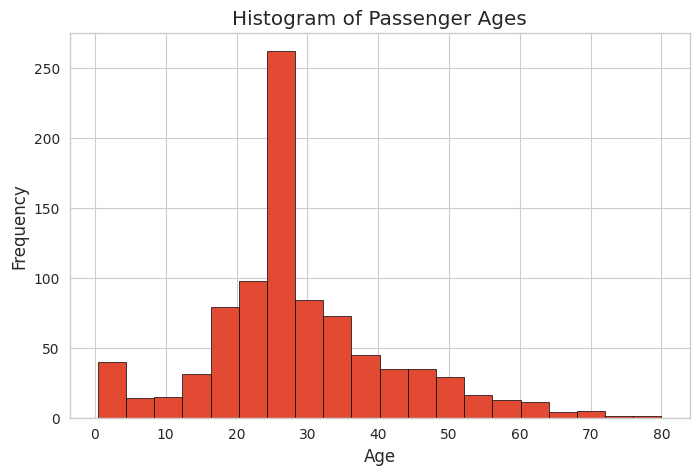

In [20]:
plt.figure(figsize=(8, 5))
plt.hist(df["Age"], bins=20, edgecolor="black")
plt.title("Histogram of Passenger Ages")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

**Insight:**  
Most passengers were young adults, with fewer very young children and elderly passenge

17) Bar Plot of Survival Rates by Passenger Class

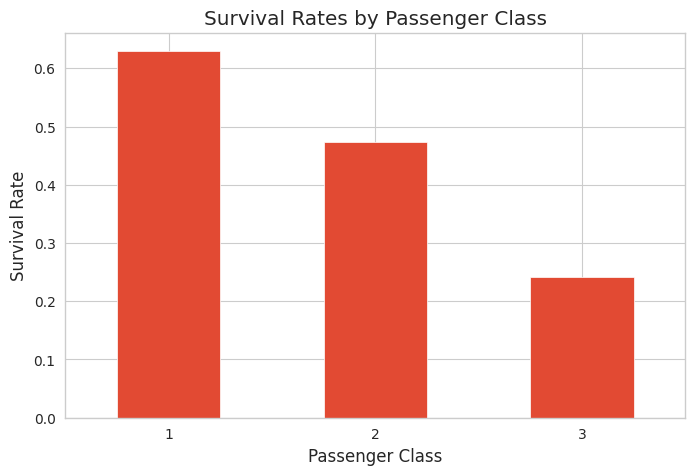

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


In [21]:
survival_by_class = df.groupby("Pclass")["Survived"].mean()

plt.figure(figsize=(8, 5))
survival_by_class.plot(kind="bar")
plt.title("Survival Rates by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.xticks(rotation=0)
plt.show()

print(survival_by_class)

**Insight:**  
Passengers in first class had a higher survival rate than passengers in second and thir

18) Correlation Heatmap

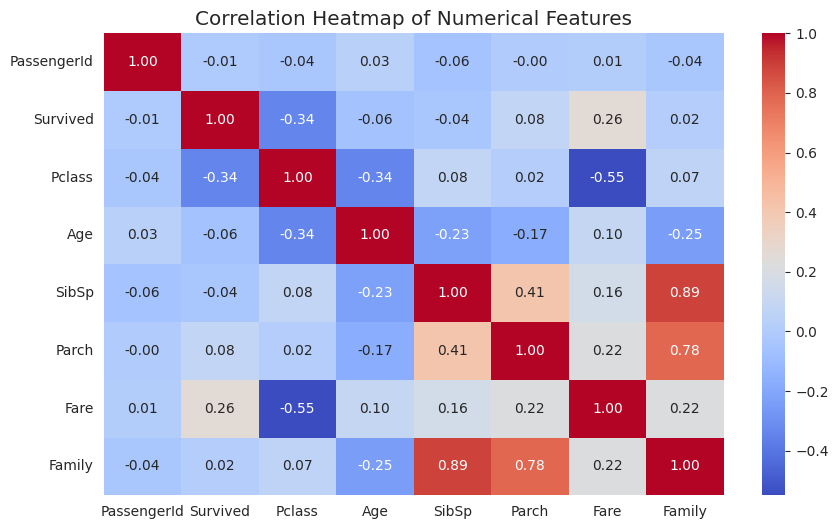

In [22]:
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

**Insight:**  
Survival shows some relationship with fare, passenger class, and family-related features.

19) Pair Plot of Selected Features

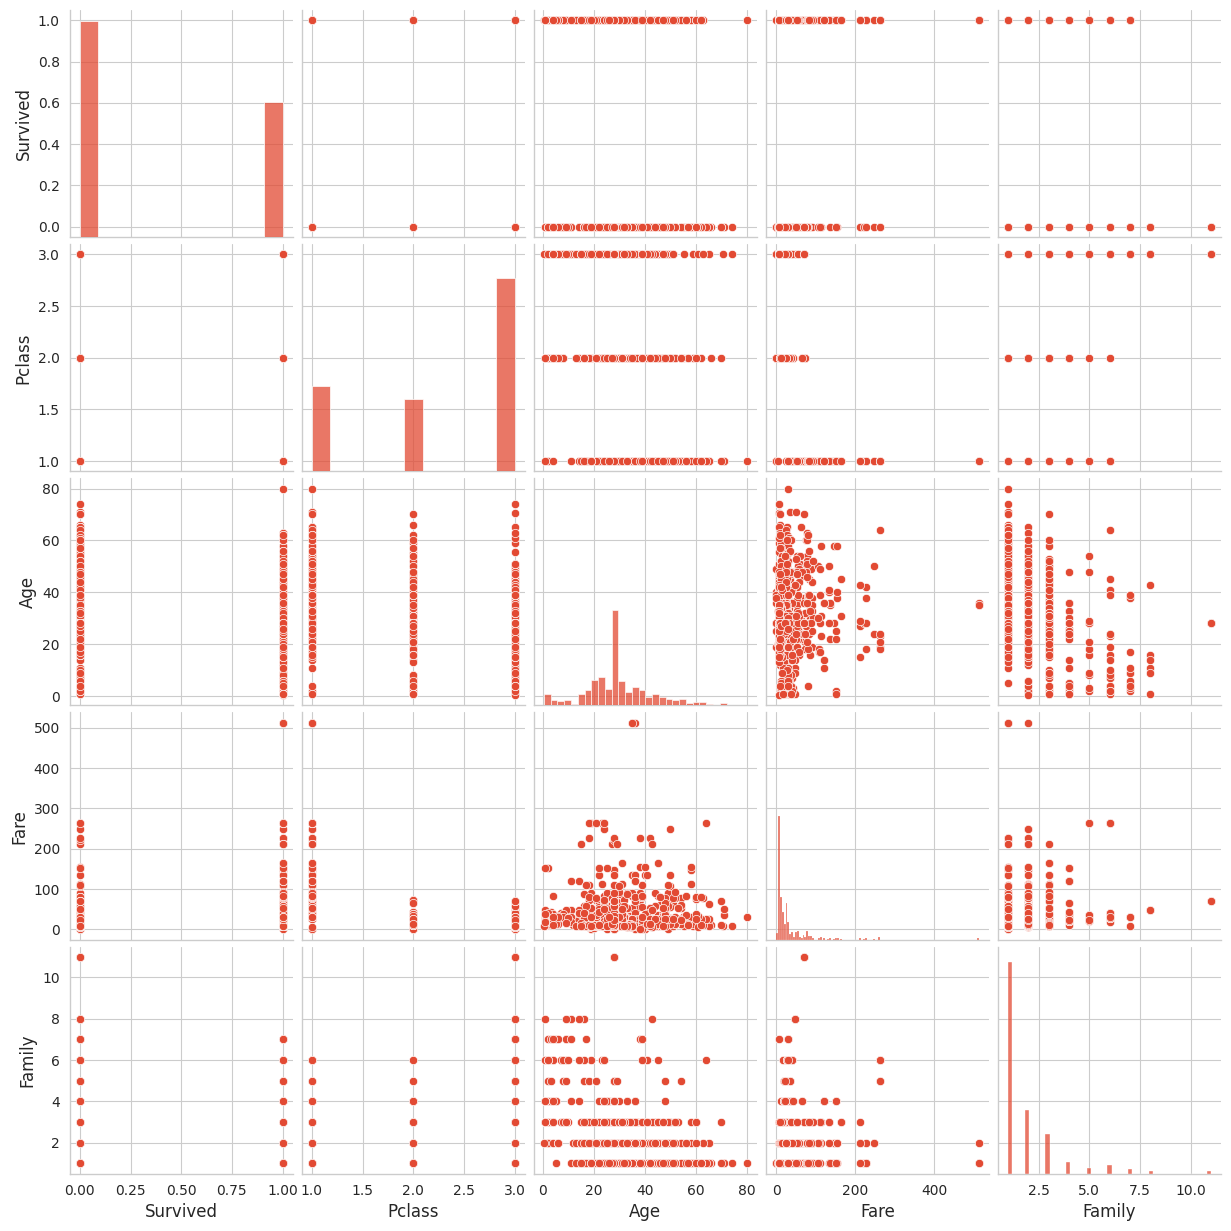

In [23]:
selected_features = df[["Survived", "Pclass", "Age", "Fare", "Family"]]
sns.pairplot(selected_features)
plt.show()

20) Analyze Survival Rates by Sex

In [24]:
survival_by_sex = df.groupby("Sex")["Survived"].mean()

print("Survival rates by sex:")
print(survival_by_sex)

Survival rates by sex:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


21) Analyze Survival Rates by Sex and Passenger Class

Survival rates by sex and passenger class:
Pclass         1         2         3
Sex                                 
female  0.968085  0.921053  0.500000
male    0.368852  0.157407  0.135447


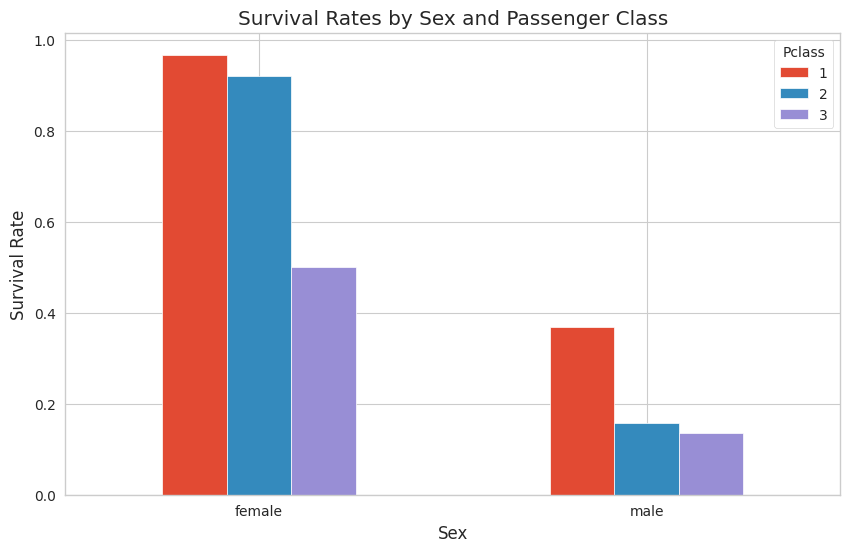

In [25]:
survival_by_sex_class = df.groupby(["Sex", "Pclass"])["Survived"].mean().unstack()

print("Survival rates by sex and passenger class:")
print(survival_by_sex_class)

survival_by_sex_class.plot(kind="bar", figsize=(10, 6))
plt.title("Survival Rates by Sex and Passenger Class")
plt.xlabel("Sex")
plt.ylabel("Survival Rate")
plt.xticks(rotation=0)
plt.legend(title="Pclass")
plt.show()

**Insight:**  
Female passengers had much higher survival rates than male passengers across all classes.  
First-class females had the highest chance of survival.

22) Box Plot for Age Distribution

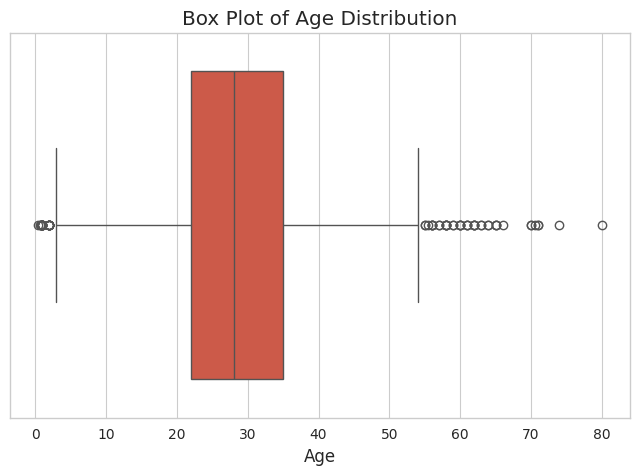

In [26]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["Age"])
plt.title("Box Plot of Age Distribution")
plt.xlabel("Age")
plt.show()

**Insight:**  
The box plot shows the central age range and highlights some outliers among older passengers.

23) Violin Plot for Fare Distribution

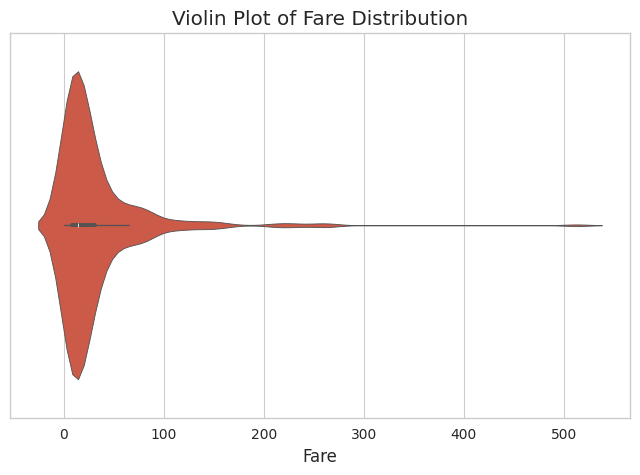

In [27]:
plt.figure(figsize=(8, 5))
sns.violinplot(x=df["Fare"])
plt.title("Violin Plot of Fare Distribution")
plt.xlabel("Fare")
plt.show()

**Insight:**  
The fare distribution is highly skewed, with most passengers paying relatively low fares and a few paying very high amounts.

24) Additional Analysis: Survival by Family Size

Survival rate by family size:
Family
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64


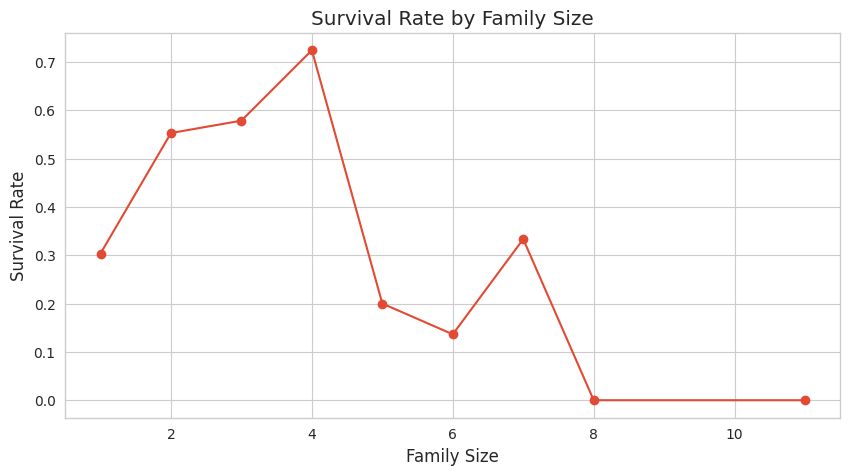

In [28]:
family_survival = df.groupby("Family")["Survived"].mean()

print("Survival rate by family size:")
print(family_survival)

plt.figure(figsize=(10, 5))
family_survival.plot(marker="o")
plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate")
plt.show()

25) Additional Analysis: Survival by Embarked Port

Survival rate by embarked port:
Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64


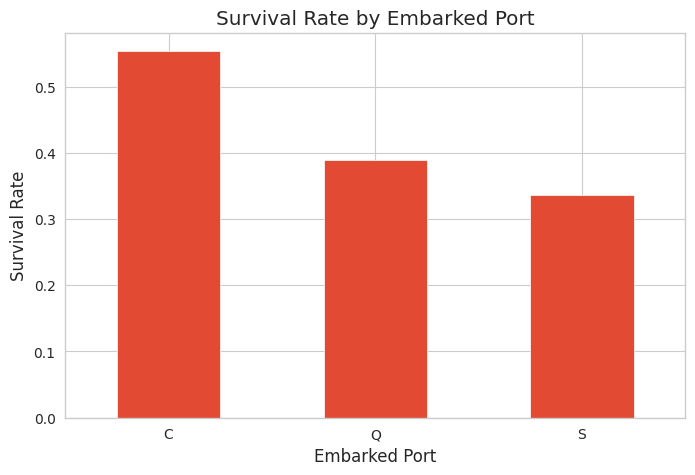

In [29]:
survival_by_embarked = df.groupby("Embarked")["Survived"].mean()

print("Survival rate by embarked port:")
print(survival_by_embarked)

plt.figure(figsize=(8, 5))
survival_by_embarked.plot(kind="bar")
plt.title("Survival Rate by Embarked Port")
plt.xlabel("Embarked Port")
plt.ylabel("Survival Rate")
plt.xticks(rotation=0)
plt.show()

26) Final Cleaned Data Preview

In [30]:
print("Final dataset preview:")
print(df.head())

print("\nFinal columns:")
print(df.columns)

Final dataset preview:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked Pclass_Category  \
0      0         A/5 21171   7.2500   NaN        S     Third Class   
1      0          PC 17599  71.2833   C85        C     First Class   
2      0  STON/O2. 3101282   7.9250   NaN        S     Third Class   
3      0         

27) Final Markdown Conclusion

# Conclusion

In this assignment, I used Pandas, Matplotlib, and Seaborn to analyze the Titanic dataset.

### Key insights:
- First-class passengers had higher survival rates than second- and third-class passengers.
- Female passengers survived at much higher rates than male passengers.
- The `Age` column had missing values, which were handled using the median.
- Fare values were highly skewed, with a small number of passengers paying very high fares.
- Family size appears to have some relationship with survival.
- Creating new features such as `Pclass_Category`, `Cabin_Category`, and `Family` helped improve the analysis.

This EDA process helped reveal important patterns in the Titanic dataset and demonstrated practical data cleaning, preprocessing, grouping, and visualization skills.

In [31]:
df.to_csv("Titanic_Cleaned.csv", index=False)
print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


Commit messages

In [33]:
!git commit -m "Load and inspect Titanic dataset"
!git commit -m "Clean data and create new features"
!git commit -m "Add visualizations and EDA insights"

fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
